# The data and its timestamps

Two questions before any economics: is the data what it claims to be, and when was
each price knowable? Below: 1040 JKM and TTF settles over 26 contracts, 1120 BLNG
settles over 28, 268 FX bars, 516 panel rows. A Singapore settle lands on the same UTC
hour in June and in January, Amsterdam and London move by an hour, and no panel row
carries a price more than 5 days old.

Rebuild with `python data.py`.

In [1]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect("../data/lng.duckdb", read_only=True)
con.execute("SET TimeZone='UTC'")  # show instants in UTC, not in the laptop's zone


def sql(query):
    return con.execute(query).df()

## What is in the database

In [2]:
sql("SELECT table_name, estimated_size AS rows FROM duckdb_tables() ORDER BY table_name")

,table_name,rows
0,freight_futures_daily,1120
1,fx_daily,268
2,lng_futures_daily,1040
3,netback_panel,516


## Contracts, not a continuous series

Each line is one contract's settle history, about 40 bars around its expiry. The gaps
are the point: the panel picks a contract per trade date along the cargo clock. It
never chains them, so no roll adjustment is ever needed and no price is invented.

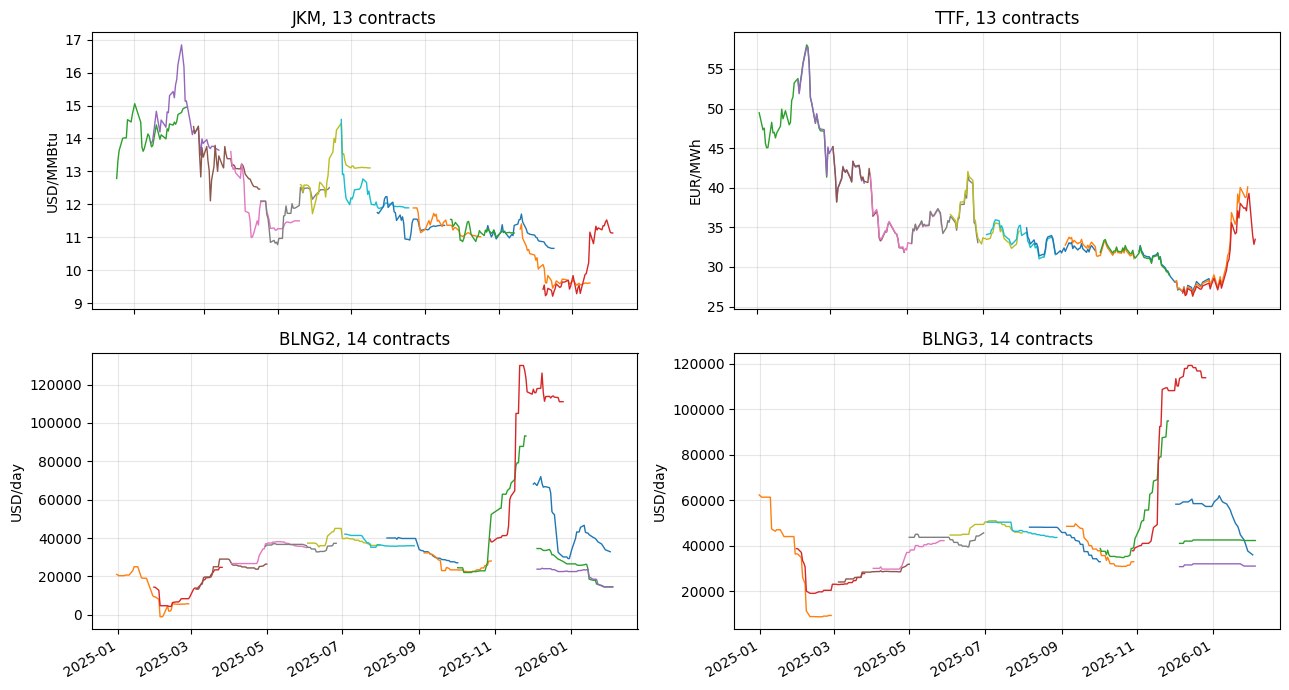

In [3]:
futures = sql("SELECT * FROM lng_futures_daily UNION ALL SELECT * FROM freight_futures_daily")
units = {"JKM": "USD/MMBtu", "TTF": "EUR/MWh", "BLNG2": "USD/day", "BLNG3": "USD/day"}

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (product, unit) in zip(axes.flat, units.items()):
    strips = futures[futures["product"] == product]
    for _, strip in strips.groupby("contract"):
        ax.plot(strip["trade_date"], strip["settle"], lw=1)
    ax.set_title(f"{product}, {strips['contract'].nunique()} contracts")
    ax.set_ylabel(unit)
    ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()

## Control 1: when was each price knowable

The same check in June and in January. Singapore has no DST, so JKM holds at 08:30 UTC
in both. Amsterdam and London shift an hour. The FX row is not a print time but an
availability rule: a bar labelled D is charged as usable only at D+1 17:00 New York, so
the panel prices TTF off the previous bar. If this table ever showed JKM moving between
the two seasons, the timezone handling would be wrong.

In [4]:
sql("""
    SELECT DISTINCT product AS source, trade_date, settle_timestamp_utc AS knowable_at
    FROM lng_futures_daily
    WHERE trade_date IN (DATE '2025-06-10', DATE '2026-01-15')
    UNION ALL
    SELECT DISTINCT product, trade_date, settle_timestamp_utc
    FROM freight_futures_daily
    WHERE product = 'BLNG2' AND trade_date IN (DATE '2025-06-10', DATE '2026-01-15')
    UNION ALL
    SELECT 'EURUSD', trade_date, available_timestamp_utc
    FROM fx_daily
    WHERE trade_date IN (DATE '2025-06-10', DATE '2026-01-15')
    ORDER BY source, trade_date
""")

,source,trade_date,knowable_at
0,BLNG2,2025-06-10,2025-06-10 15:00:00+00:00
1,BLNG2,2026-01-15,2026-01-15 16:00:00+00:00
2,EURUSD,2025-06-10,2025-06-11 21:00:00+00:00
3,EURUSD,2026-01-15,2026-01-16 22:00:00+00:00
4,JKM,2025-06-10,2025-06-10 08:30:00+00:00
5,JKM,2026-01-15,2026-01-15 08:30:00+00:00
6,TTF,2025-06-10,2025-06-10 15:00:00+00:00
7,TTF,2026-01-15,2026-01-15 16:00:00+00:00


## Control 2: how old is the oldest price on a row

Age in calendar days of the oldest input behind each panel row. Nothing passes 5: the
joins carry that tolerance and drop the row rather than carry a price forward. Rotterdam
never reads 0 because its FX leg is lagged a day on purpose, so 1 is its floor by
construction, not a data problem.

In [5]:
sql("""
    SELECT route, max_staleness_days, COUNT(*) AS rows
    FROM netback_panel
    GROUP BY route, max_staleness_days
    ORDER BY route, max_staleness_days
""").pivot(index="route", columns="max_staleness_days", values="rows").fillna(0).astype(int)

max_staleness_days,0,1,2,3,4
route,,,,,
us_gulf_to_rotterdam,0,216,2,28,2
us_gulf_to_tokyo,256,11,0,1,0
